# Rating analysis

The same questions are rated by the human evaluators **LZ** and **KB**, and by
the **Claude** and **Codex** LLM judges — each judge twice, once with the
reference solution in hand (*supervised*, columns `claude` / `codex`) and once
without it (*unsupervised*, columns `claude_unsup` / `codex_unsup`).

Throughout: *rater* = who gave the rating (LZ / KB / claude / codex);
*agent* = the system being evaluated (claude-code / codex).

LZ's rating is the reference — where a judge was once found more accurate,
that judgement was folded into LZ's own rating, so LZ stands alone as truth.

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

%load_ext autoreload
%autoreload 2

from analysis import (add_null, agreement, binary, correctness_only, display,
                      coverage_summary, load_ratings, summary_table,
                      unanswered_by_judges, uniform_variables)  # noqa: F401

pd.set_option("display.width", 140)
pd.set_option("display.max_rows", 120)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load

Human ratings come from each evaluator's dossier copies; judge ratings from
`eval/<dataset>/judge_supervised/` and `judge_unsupervised/`, mapped onto our
question numbering by content rather than by number (the judges ask their own
list, and the two numberings have drifted apart).

Any pairing made on the question number rather than its content warns on
stderr — those are cases where the same variable is spelled differently
(`photostim` vs `Photostimulation`), and they are worth a glance. Each warning
now appears twice, once per judge run.

"How is memory usage optimized?" is dropped everywhere: it was added to the
references after the judges ran, so no judge ever answered it.

In [20]:
ratings = load_ratings()          # both judge runs; judge_modes= to pick one
ratings

Ratings(8 datasets, 1428 rows, LZ=1428, KB=1428, claude=1428, codex=1428, claude_unsup=1428, codex_unsup=1428)

Questions dropped from every analysis below:

In [21]:
ratings.excluded

,dataset,qid,title
0,allen2p,9-e,How is memory usage optimized?
1,lee2025,6-e,How is memory usage optimized?
2,majnik2025,6-e,How is memory usage optimized?
3,sosa2024,13-e,How is memory usage optimized?
4,chen2024,10-e,How is memory usage optimized?
5,hasnain2024,11-e,How is memory usage optimized?
6,zhang2025,10-e,How is memory usage optimized?
7,zhong2025,12-e,How is memory usage optimized?


### Coverage

Cells = questions x 6 trials. Gaps are real and stay as NaN rather than
becoming zeros: KB has not rated zhong2025, and is one question short in
three datasets.

In [22]:
coverage_summary(ratings)

rater,LZ,KB,claude,codex,claude_unsup,codex_unsup,cells
dataset,,,,,,,
allen2p,174,174,174,174,174,174,174
lee2025,120,120,120,120,120,120,120
majnik2025,126,126,126,126,126,126,126
sosa2024,234,234,234,234,234,234,234
chen2024,180,180,180,180,180,180,180
hasnain2024,198,198,198,198,198,198,198
zhang2025,180,180,180,180,180,180,180
zhong2025,216,216,216,216,216,216,216


Every remaining question is answered by both judges — this should be empty.

In [23]:
unanswered_by_judges(ratings)

,dataset,mode,qid,title


In [24]:
# `LZ_null` is LZ's own ratings shuffled: the same number of every rating
# level, but attached to the wrong trials. It is the floor to read the real
# raters against. Shuffled separately in each frame so its distribution matches
# whichever subset that table uses.
tidy = add_null(ratings.tidy)

# Agreement is about whether two raters call the same code correct, so the
# Code Efficiency questions — performance advice rather than a correctness
# check — are excluded from section 3. Section 4 keeps them; swap in
# `correct_only` there too if you want the binary numbers on the same subset.
correct_only = add_null(correctness_only(ratings.tidy))
print(f"{len(tidy)} rows total, {len(correct_only)} after dropping "
      f"{sorted(set(tidy.category) - set(correct_only.category))}")
tidy.head()

1428 rows total, 1236 after dropping ['Code Efficiency']


,dataset,qid,main,sub,title,category,subtype,var_label,agent,trial,...,KB,claude,claude_code,codex,codex_code,claude_unsup,claude_unsup_code,codex_unsup,codex_unsup_code,LZ_null
0,allen2p,1-a,1,a,"How are **all the data** for all subjects, ses...",Data Loading,Overall,None,claude-code,1,...,-2,0,CORRECT,-2,CORRECT,1,CORRECT,1,CORRECT,1.0
1,allen2p,1-a,1,a,"How are **all the data** for all subjects, ses...",Data Loading,Overall,None,claude-code,2,...,-2,-1,CORRECT,-1,CORRECT,1,CORRECT,1,CORRECT,1.0
2,allen2p,1-a,1,a,"How are **all the data** for all subjects, ses...",Data Loading,Overall,None,claude-code,3,...,-2,0,CORRECT,-2,CORRECT,1,CORRECT,1,CORRECT,-2.0
3,allen2p,1-a,1,a,"How are **all the data** for all subjects, ses...",Data Loading,Overall,None,codex,1,...,-2,0,CORRECT,-2,CORRECT,1,CORRECT,1,CORRECT,1.0
4,allen2p,1-a,1,a,"How are **all the data** for all subjects, ses...",Data Loading,Overall,None,codex,2,...,-2,0,CORRECT,-2,CORRECT,1,CORRECT,-1,INCORRECT,1.0


## 2. Summary visualisation

One column per dataset, one row per question, six cells per row (3 trials x
2 agents). Pass any rater.

The `Thresholding` sub-block is left out by default — only sosa2024 has those
two questions, so showing them costs a row band across every column.

`EXCLUDE_VARS` drops variables whose source and processing questions are
rated `match` in every trial: every cell the same colour, so the row says
nothing. That is an editorial call, so it lives here rather than in the
package — edit the dict to change the figure. `uniform_variables(tidy)` lists
the candidates. Nothing here affects the numbers in sections 3 and 4.

In [25]:
EXCLUDE_VARS = {
    "sosa2024": ("input: Environment type", "input: Trial number",
                 "output: Reward outcome"),
    "zhong2025": ("input: reward_availability", "output: licking"),
}

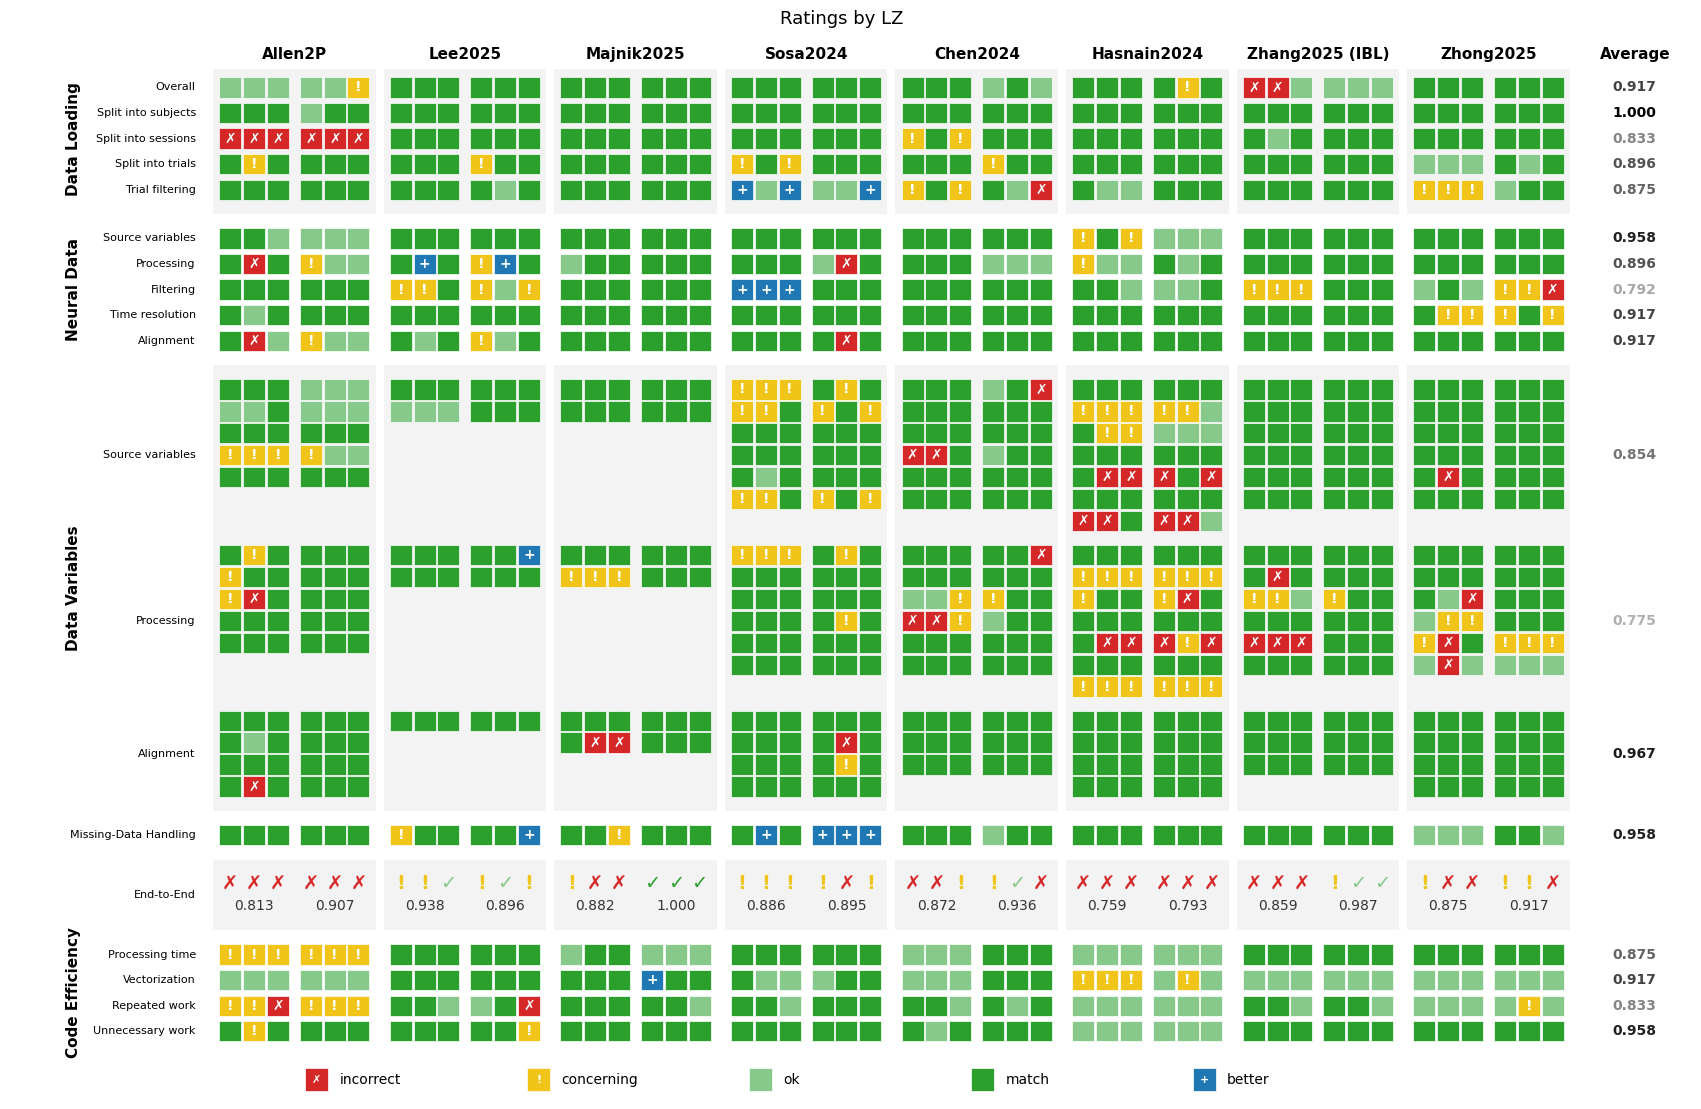

In [26]:
fig, _ = summary_table(ratings, rater="LZ", exclude_variables=EXCLUDE_VARS)
plt.show()

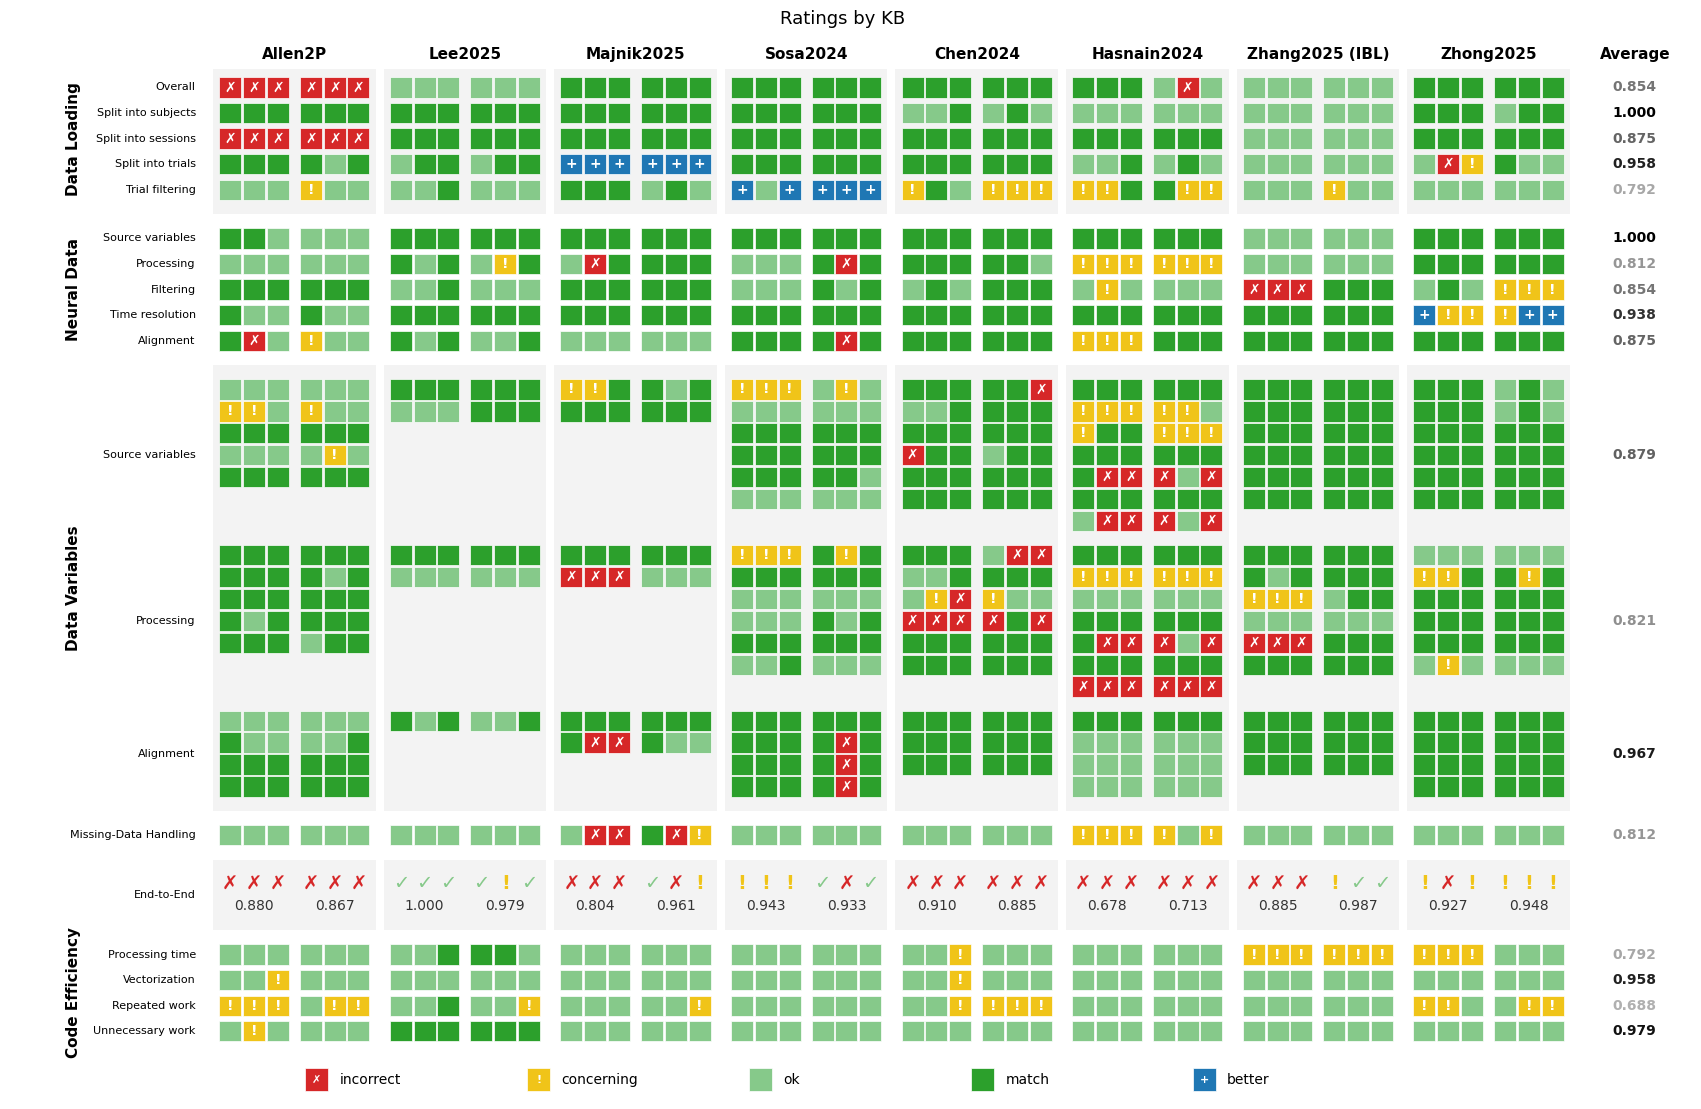

In [27]:
fig, _ = summary_table(ratings, rater="KB", exclude_variables=EXCLUDE_VARS)
plt.show()

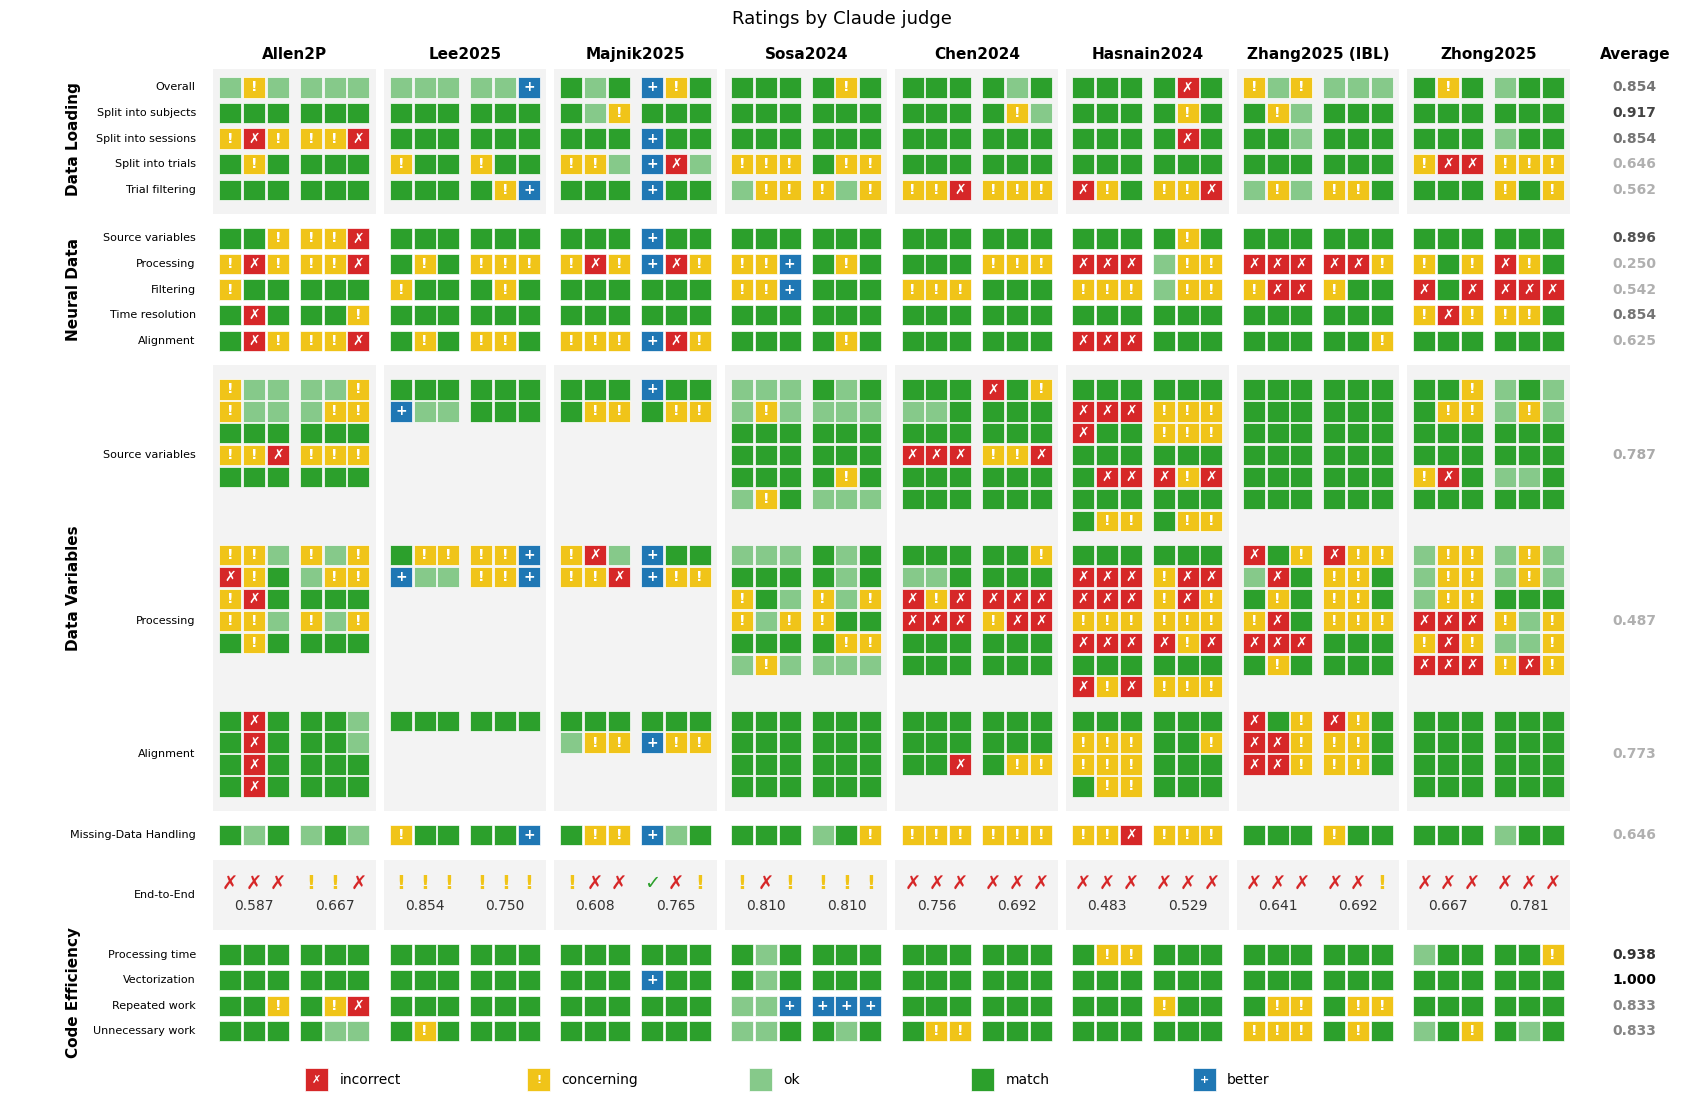

In [28]:
fig, _ = summary_table(ratings, rater="claude", exclude_variables=EXCLUDE_VARS)
plt.show()

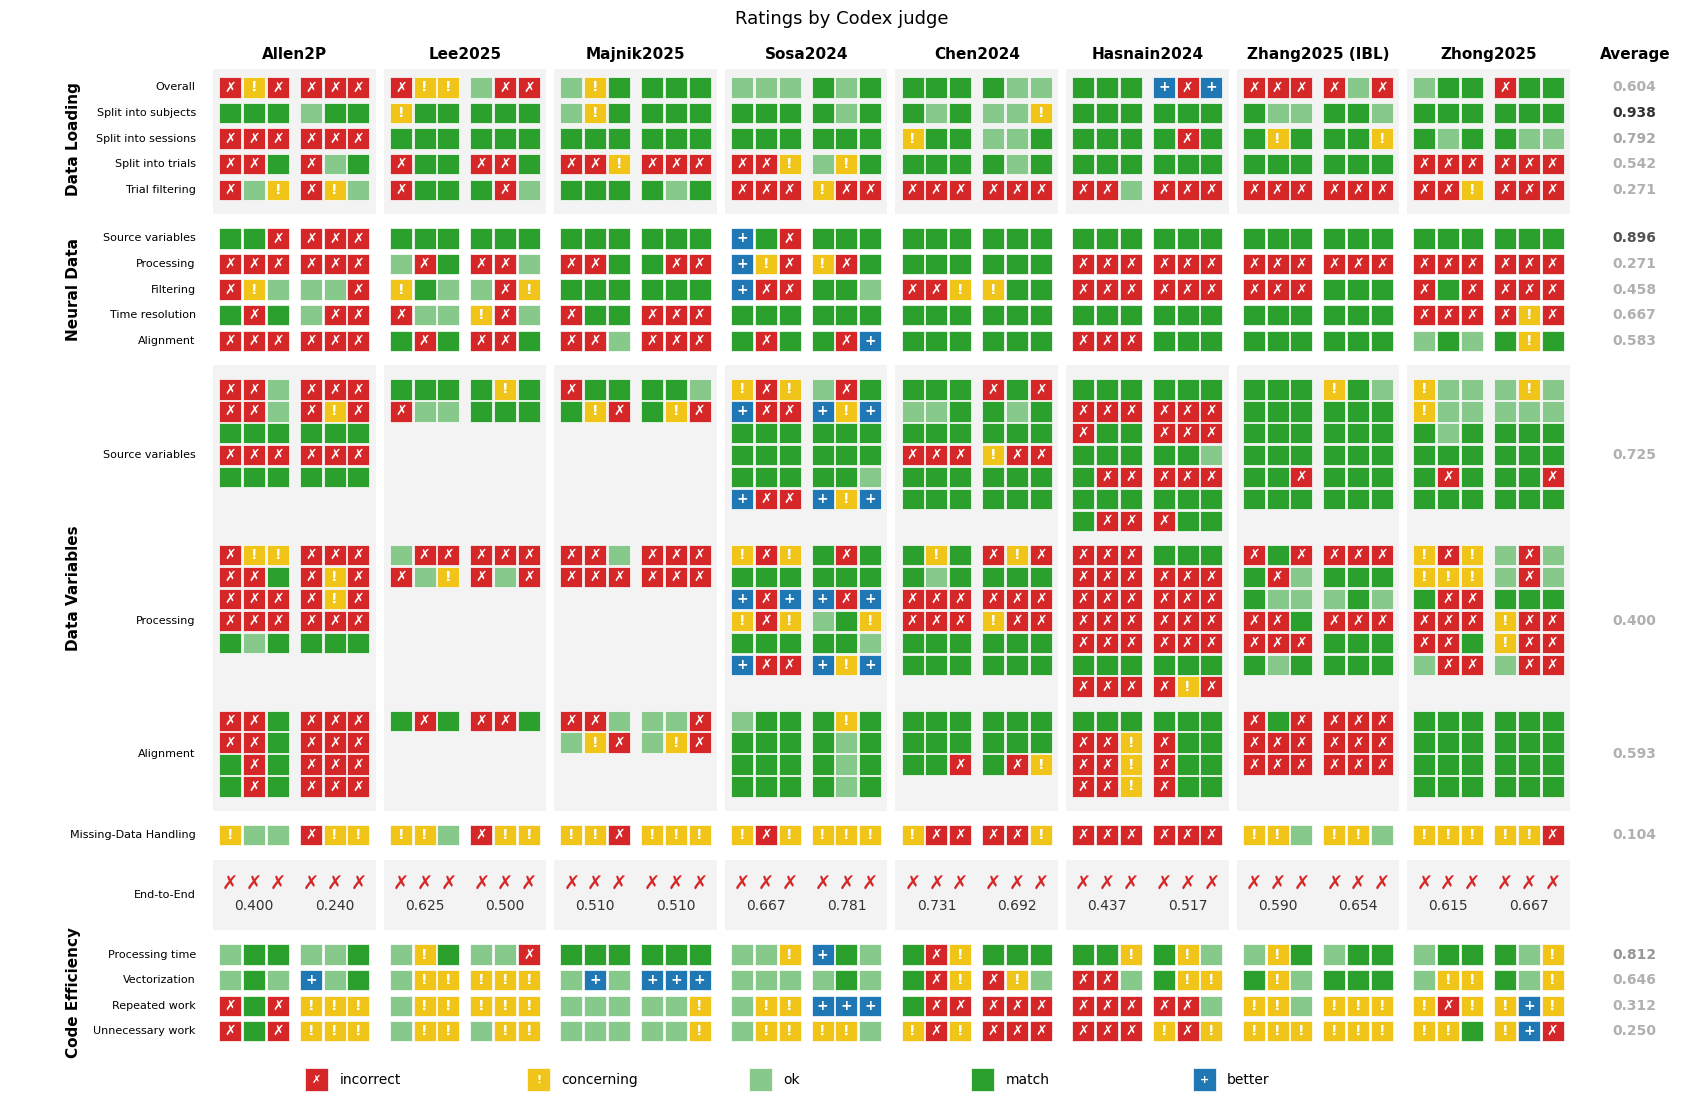

In [29]:
fig, _ = summary_table(ratings, rater="codex", exclude_variables=EXCLUDE_VARS)
plt.show()

## 3. Agreement between raters

Two measures per pair, over the rows where both rated:

| measure | reads as |
|---|---|
| `pearson` | linear agreement, treating -2..2 as an interval scale |
| `kappa` | Cohen's kappa, linearly weighted — chance-corrected |

Read `kappa` first: it discounts the agreement that the skew toward "match"
buys for free. The **LZ-KB** row is the human-human ceiling the judge rows
should be compared against.

The first block is every pair anchored on a human rater, ending with the
unsupervised judges against LZ — what withholding the reference solution
costs against the human reference. The second block is judge against judge:
the two judges against each other, and each judge against its own
unsupervised run, i.e. how much the reference solution changed its mind at all.

Correctness questions only — the Code Efficiency block is excluded.

The last row is the null: LZ against a shuffled copy of LZ. Both measures
should sit at ~0 by construction — that is the floor.

In [30]:
# Two blocks: every pair anchored on a human rater, then the judge-against-judge
# pairs — the two judges against each other, and each judge against its own run
# without the reference solution.
HUMAN_PAIRS = [("LZ", "KB"),
               ("LZ", "claude"), ("LZ", "codex"),
               ("KB", "claude"), ("KB", "codex"),
               ("LZ", "claude_unsup"), ("LZ", "codex_unsup")]
JUDGE_PAIRS = [("claude", "codex"),
               ("claude", "claude_unsup"), ("codex", "codex_unsup")]

agree = pd.concat(
    [agreement.pairwise(correct_only, pairs=HUMAN_PAIRS + JUDGE_PAIRS),
     agreement.pairwise(correct_only, pairs=[("LZ", "LZ_null")])],
    ignore_index=True)
display.agreement(agree)

Rater A,Rater B,Pearson r,Cohen's κ
Human #1,Human #2,0.575,0.434
Human #1,Claude,0.466,0.332
Human #1,Codex,0.370,0.218
Human #2,Claude,0.482,0.375
Human #2,Codex,0.461,0.301
Human #1,Claude Unsup,0.212,0.169
Human #1,Codex Unsup,0.271,0.227
Claude,Codex,0.653,0.511
Claude,Claude Unsup,0.241,0.151
Codex,Codex Unsup,0.384,0.286


In [37]:
print(display.agreement_latex(
    agree, caption="Agreement between raters on the correctness questions.",
    label="tab:rater-agreement"))

\begin{table}
\caption{Agreement between raters on the correctness questions.}
\label{tab:rater-agreement}
\begin{tabular}{llrr}
\toprule
Rater A & Rater B & Pearson r & Cohen's $\kappa$ \\
\midrule
Human \#1 & Human \#2 & 0.575 & 0.434 \\
Human \#1 & Claude & 0.466 & 0.332 \\
Human \#1 & Codex & 0.370 & 0.218 \\
Human \#2 & Claude & 0.482 & 0.375 \\
Human \#2 & Codex & 0.461 & 0.301 \\
Human \#1 & Claude Unsup & 0.212 & 0.169 \\
Human \#1 & Codex Unsup & 0.271 & 0.227 \\
Claude & Codex & 0.653 & 0.511 \\
Claude & Claude Unsup & 0.241 & 0.151 \\
Codex & Codex Unsup & 0.384 & 0.286 \\
Human \#1 & Human Null & -0.022 & -0.018 \\
\bottomrule
\end{tabular}
\end{table}



In [38]:
print(display.agreement_markdown(agree))

| Rater A  | Rater B      | Pearson r | Cohen's κ |
| -------- | ------------ | --------: | --------: |
| Human #1 | Human #2     |     0.575 |     0.434 |
| Human #1 | Claude       |     0.466 |     0.332 |
| Human #1 | Codex        |     0.370 |     0.218 |
| Human #2 | Claude       |     0.482 |     0.375 |
| Human #2 | Codex        |     0.461 |     0.301 |
| Human #1 | Claude Unsup |     0.212 |     0.169 |
| Human #1 | Codex Unsup  |     0.271 |     0.227 |
| Claude   | Codex        |     0.653 |     0.511 |
| Claude   | Claude Unsup |     0.241 |     0.151 |
| Codex    | Codex Unsup  |     0.384 |     0.286 |
| Human #1 | Human Null   |    -0.022 |    -0.018 |


### By dataset

Where a judge tracks the humans well and where it does not.

In [32]:
# Every pair is anchored on LZ, the reference, plus claude-vs-codex to
# show the two judges against each other. KB-vs-judge pairs are in the
# overall table above; six columns per dataset is too wide to read.
PAIRS = [("LZ", "KB"), ("LZ", "claude"), ("LZ", "codex"),
         ("claude", "codex")]

by_ds = agreement.pairwise(correct_only, by="dataset", pairs=PAIRS)
by_ds.pivot(index="dataset", columns=["rater_a", "rater_b"], values="kappa").round(3)

rater_a         LZ               claude
rater_b         KB claude  codex  codex
dataset                                
allen2p      0.450  0.489  0.161  0.339
chen2024     0.503  0.375  0.329  0.757
hasnain2024  0.434  0.354  0.245  0.681
lee2025      0.295  0.343  0.116  0.301
majnik2025   0.379  0.176  0.083  0.370
sosa2024     0.419  0.180  0.157  0.282
zhang2025    0.410  0.237  0.181  0.604
zhong2025    0.369  0.332  0.325  0.570

## 4. Binary accuracy — catching mistakes

Collapse the five levels into a two-level decision, with **incorrect as the
positive class**, and treat LZ as truth:

* `incorrect` = rating <= -1 (concerning / incorrect) — the event to detect
* `correct` = rating >= 0 (ok / match / better)

So the numbers say how well each rater catches the mistakes LZ found:

| | |
|---|---|
| `recall` | share of real mistakes caught |
| `precision` | share of its flags that were real mistakes |
| `f1` | harmonic mean of the two |

Both judge runs are here: `Claude` / `Codex` saw the reference solution,
`Claude Unsup` / `Codex Unsup` did not.

`accuracy` is deliberately not the headline — mistakes are rare, so a rater
that flags nothing scores well on it. The `LZ_null` row is the floor.

In [33]:
PREDICTORS = ("KB", "claude", "codex", "claude_unsup", "codex_unsup", "LZ_null")
bin_all = binary.table(tidy, "LZ", PREDICTORS)
display.binary(bin_all)

Rater,Balanced Acc,Recall,Precision,F1,TP,FP,FN,TN
Human #2,0.742,0.543,0.543,0.543,89,75,75,1189
Claude,0.717,0.665,0.273,0.387,109,291,55,973
Codex,0.713,0.805,0.216,0.341,132,479,32,785
Claude Unsup,0.582,0.238,0.295,0.264,39,93,125,1171
Codex Unsup,0.651,0.506,0.244,0.329,83,257,81,1007
Human Null,0.487,0.091,0.091,0.091,15,149,149,1115


In [39]:
print(display.binary_latex(
    bin_all, caption="Catching the mistakes the reference evaluator found.",
    label="tab:binary-accuracy"))

\begin{table}
\caption{Catching the mistakes the reference evaluator found.}
\label{tab:binary-accuracy}
\begin{tabular}{lrrrrrrrr}
\toprule
Rater & Balanced Acc & Recall & Precision & F1 & TP & FP & FN & TN \\
\midrule
Human \#2 & 0.742 & 0.543 & 0.543 & 0.543 & 89 & 75 & 75 & 1189 \\
Claude & 0.717 & 0.665 & 0.273 & 0.387 & 109 & 291 & 55 & 973 \\
Codex & 0.713 & 0.805 & 0.216 & 0.341 & 132 & 479 & 32 & 785 \\
Claude Unsup & 0.582 & 0.238 & 0.295 & 0.264 & 39 & 93 & 125 & 1171 \\
Codex Unsup & 0.651 & 0.506 & 0.244 & 0.329 & 83 & 257 & 81 & 1007 \\
Human Null & 0.487 & 0.091 & 0.091 & 0.091 & 15 & 149 & 149 & 1115 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
print(display.binary_markdown(bin_all))

### Judge on its own agent vs the other agent

Does a judge rate the agent that shares its model more leniently? Split the
same table by which agent produced the trial.

In [35]:
by_agent = binary.table(tidy, "LZ", ("claude", "codex"), by="agent")
display.binary(by_agent)

agent,Rater,Balanced Acc,Recall,Precision,F1,TP,FP,FN,TN
claude-code,Claude,0.731,0.697,0.322,0.441,69,145,30,470
claude-code,Codex,0.729,0.828,0.265,0.401,82,228,17,387
codex,Claude,0.695,0.615,0.215,0.319,40,146,25,503
codex,Codex,0.691,0.769,0.166,0.273,50,251,15,398


In [36]:
print(display.binary_latex(
    by_agent, caption="Judge accuracy on its own agent versus the other agent.",
    label="tab:judge-self-cross"))
print(display.binary_markdown(by_agent))

\begin{table}
\caption{Judge accuracy on its own agent versus the other agent.}
\label{tab:judge-self-cross}
\begin{tabular}{llrrrrrrrr}
\toprule
agent & Rater & Balanced Acc & Recall & Precision & F1 & TP & FP & FN & TN \\
\midrule
claude-code & Claude & 0.731 & 0.697 & 0.322 & 0.441 & 69 & 145 & 30 & 470 \\
claude-code & Codex & 0.729 & 0.828 & 0.265 & 0.401 & 82 & 228 & 17 & 387 \\
codex & Claude & 0.695 & 0.615 & 0.215 & 0.319 & 40 & 146 & 25 & 503 \\
codex & Codex & 0.691 & 0.769 & 0.166 & 0.273 & 50 & 251 & 15 & 398 \\
\bottomrule
\end{tabular}
\end{table}

| agent       | Rater  | Balanced Acc | Recall | Precision |    F1 |  TP |  FP |  FN |  TN |
| ----------- | ------ | -----------: | -----: | --------: | ----: | --: | --: | --: | --: |
| claude-code | Claude |        0.731 |  0.697 |     0.322 | 0.441 |  69 | 145 |  30 | 470 |
| claude-code | Codex  |        0.729 |  0.828 |     0.265 | 0.401 |  82 | 228 |  17 | 387 |
| codex       | Claude |        0.695 |  0.615 |     0.215